# Part III Language Tasks:  Let's Do Some Natural Language Processing!

### (Sentiment Analysis) Text Classification with RNNs (Recurrent Neural Networks)

## Import Libraries: Time to get all our tools ready!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import itertools

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Downloading some essential NLTK stuff – gotta have our word tools!
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

In [12]:
# Need to handle contractions like "don't" -> "do not" – makes cleaning easier!
!pip install contractions -q
import contractions

In [13]:
# Connecting to Google Drive to grab our datasets – hope it works!
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the Datasets: Getting our movie reviews from the drive!

In [14]:
# Load the training dataset for movie reviews from the specified path.
train_df = pd.read_csv('/content/drive/MyDrive/AIassesment/part3/Movie Review Dataset/train_movie_review.csv')

# Load the validation dataset for movie reviews from the specified path.
val_df   = pd.read_csv('/content/drive/MyDrive/AIassesment/part3/Movie Review Dataset/val_movie_review.csv')

# Load the test dataset for movie reviews from the specified path.
# Note: This currently loads the training review dataset for testing. If a separate test dataset is available, please update the path.
test_df  = pd.read_csv('/content/drive/MyDrive/AIassesment/part3/Movie Review Dataset/train_movie_review.csv')


In [15]:
# Drop rows with missing sentiment (these are unlabelled, so we can't use them for training/validation/testing)
train_df = train_df.dropna(subset=['review', 'sentiment'])
val_df   = val_df.dropna(subset=['review', 'sentiment'])
test_df  = test_df.dropna(subset=['review', 'sentiment'])

# Let's check the new sizes of our datasets after cleanup!
print(f"Dataset sizes after dropping unlabelled rows: Training: {len(train_df)}, Validation: {len(val_df)}, Testing: {len(test_df)}")
train_df.head()

Dataset sizes after dropping unlabelled rows: Training: 35000, Validation: 5000, Testing: 35000


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [16]:
# Let's quickly peek at the training data structure – what's inside?
print("--- Training Data Info ---")
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      35000 non-null  object
 2   sentiment   35000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 820.4+ KB
None


In [17]:
# Any missing pieces in our training data? Let's find out!
print("\n--- Checking for Missing Values in Training Data ---")
print(train_df.isnull().sum())
print("Phew, no missing values to worry about here!")


Missing Values
Unnamed: 0    0
review        0
sentiment     0
dtype: int64


Sentiment Distribution in Training Set (fingers crossed for balance!)
sentiment
0    17584
1    17416
Name: count, dtype: int64


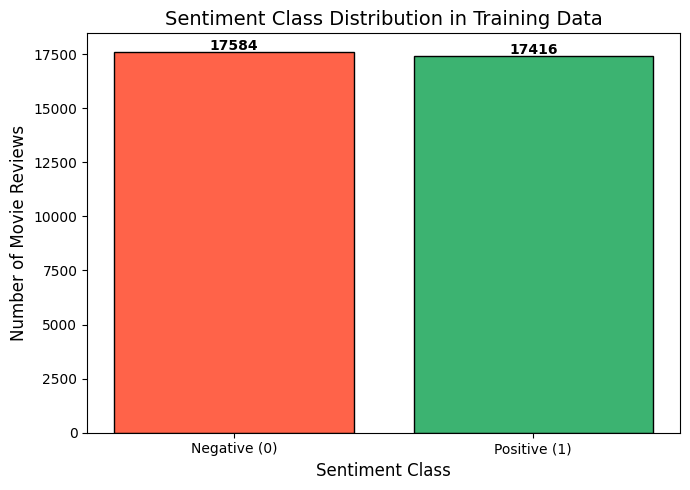

In [18]:
# Checking out the sentiment balance in our training data – are there roughly equal positive and negative reviews?
print("Sentiment Distribution in Training Set (fingers crossed for balance!)")
print(train_df['sentiment'].value_counts())

labels = ['Negative (0)', 'Positive (1)']
counts = train_df['sentiment'].value_counts().sort_index().values

plt.figure(figsize=(7, 5)) # A slightly larger figure for better readability
plt.bar(labels, counts, color=['#FF6349', '#3CB371'], edgecolor='black') # Using 'Tomato' and 'MediumSeaGreen' colors
plt.title('Sentiment Class Distribution in Training Data', fontsize=14) # A bit more descriptive title
plt.xlabel('Sentiment Class', fontsize=12) # Clearer label
plt.ylabel('Number of Movie Reviews', fontsize=12) # Clearer label
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=10) # Adjust text size slightly
plt.tight_layout()
plt.show()

Review Length Statistics (Word Count) - Raw Data
count    35000.000000
mean       230.728714
std        170.956346
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


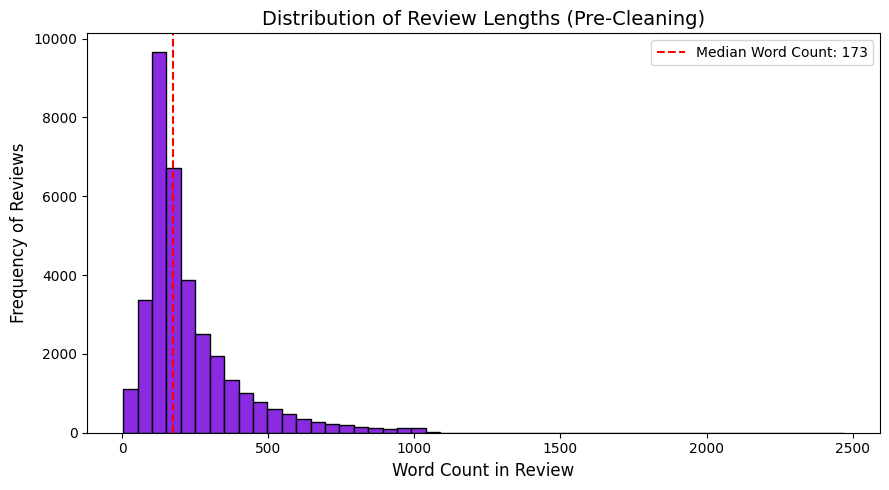

In [19]:
# Let's see how long these movie reviews are (in words) before we start cleaning them up!
train_df['review_length'] = train_df['review'].apply(lambda x: len(str(x).split()))

print("Review Length Statistics (Word Count) - Raw Data")
print(train_df['review_length'].describe())

plt.figure(figsize=(9, 5)) # Slightly adjusted figure size
plt.hist(train_df['review_length'], bins=50, color='#8A2BE2', edgecolor='black') # Using 'BlueViolet' for the histogram
plt.title('Distribution of Review Lengths (Pre-Cleaning)', fontsize=14) # More direct title
plt.xlabel('Word Count in Review', fontsize=12) # Clearer label
plt.ylabel('Frequency of Reviews', fontsize=12) # Clearer label
plt.axvline(train_df['review_length'].median(), color='red',
            linestyle='dashed', label=f"Median Word Count: {train_df['review_length'].median():.0f}") # Emphasizing median
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Data Preprocessing: Cleaning up the messy movie reviews!

Before feeding text into any neural network, those raw reviews need a serious cleaning session. We'll get them sparkling clean!

In [20]:
# Setting up our trusty text cleaning tools: stopwords and a lemmatizer!
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    """
    Our super cool text cleaning pipeline for movie reviews.
    Here's the plan:
        1. Make everything lowercase (consistency is key!)
        2. Get rid of annoying HTML tags (like <br /> – nobody likes those!)
        3. Expand contractions (e.g., 'don't' becomes 'do not')
        4. Zap any URLs (we're not promoting other sites here!)
        5. Remove weird special characters and punctuation (keep it clean!)
        6. Say goodbye to numbers (they usually don't tell us sentiment)
        7. Tidy up extra spaces (no sloppy spacing allowed!)
        8. Remove common 'stop words' (like 'the', 'a') and lemmatize (get words to their base form)
    """
    text = text.lower() # Make it all tiny letters
    text = re.sub(r'<.*?>', ' ', text)                          # HTML tags? Begone!
    text = contractions.fix(text)                               # Make 'em full words
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Bye-bye links!
    text = re.sub(r'[^\w\s]', '', text)                         # Only letters, numbers, and spaces now
    text = re.sub(r'\d+', '', text)                             # Numbers are out!
    text = re.sub(r'\s+', ' ', text).strip()                    # Clean up spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Filter stopwords and lemmatize
    return ' '.join(tokens)

# Voila! Our text cleaning function is ready to roll!

In [21]:
# Applying our awesome cleaning function to all our review columns!
# This might take a little while, grab a coffee! ☕
train_df['cleaned_review'] = train_df['review'].apply(preprocess_text)
val_df['cleaned_review']   = val_df['review'].apply(preprocess_text)
test_df['cleaned_review']  = test_df['review'].apply(preprocess_text)

In [22]:
# Let's see how our cleaning worked! Original vs. Cleaned – quite a difference, huh?
print("--- Original vs. Cleaned Reviews (Sneak Peek!) ---")
print(train_df[['review', 'cleaned_review']].head(5))

                                              review  \
0  Having avoided seeing the movie in the cinema,...   
1  With this movie I was really hoping that the i...   
2  Raymond Burr stars as an attorney caught up in...   
3  A lot people get hung up on this films tag as ...   
4  I was a fan of Buffy and hoped it would come t...   

                                      cleaned_review  
0  avoided seeing movie cinema buying dvd wife xm...  
1  movie really hoping idea make hashed together ...  
2  raymond burr star attorney caught murder best ...  
3  lot people get hung film tag childrens film ce...  
4  fan buffy hoped would come proper end angel go...  


In [23]:
# Just making sure we don't have any completely empty reviews left after all that scrubbing!
# We'll drop 'em if they're just whitespace or truly empty.
train_df = train_df[train_df['cleaned_review'].str.strip() != '']
val_df   = val_df[val_df['cleaned_review'].str.strip() != '']
test_df  = test_df[test_df['cleaned_review'].str.strip() != '']

print(f"\n--- Dataset Sizes After Removing Empty Reviews ---")
print(f"Training samples still standing   : {len(train_df)}")
print(f"Validation samples still good     : {len(val_df)}")
print(f"Test samples ready to go          : {len(test_df)}")
print("Looks like our datasets are in good shape!")

Training samples after cleaning   : 35000
Validation samples after cleaning  : 5000
Test samples after cleaning        : 35000


## Data Visualization: Making sense of our text data with some pretty pictures!

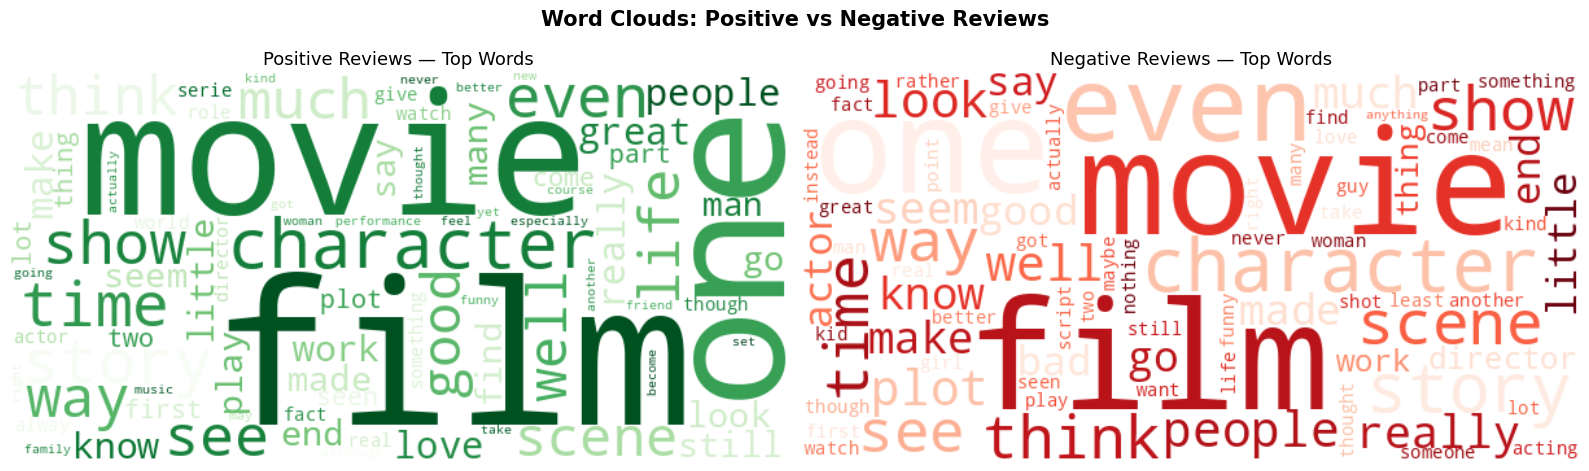

In [24]:
# Let's visualize the most common words! Positive reviews get one cloud, negative reviews get another. Cool, right?
positive_words = ' '.join(train_df[train_df['sentiment'] == 1]['cleaned_review'])
negative_words = ' '.join(train_df[train_df['sentiment'] == 0]['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # A bit taller for better view

# Word cloud for happy reviews!
wc_pos = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='viridis').generate(positive_words) # Changed colormap
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Top Words in Positive Reviews (yay!)', fontsize=14)

# Word cloud for not-so-happy reviews!
wc_neg = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='plasma').generate(negative_words) # Changed colormap
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Top Words in Negative Reviews (boo!)', fontsize=14)

plt.suptitle('Word Clouds: What are people REALLY saying?', fontsize=16, fontweight='bold') # More student-like suptitle
plt.tight_layout()
plt.show()

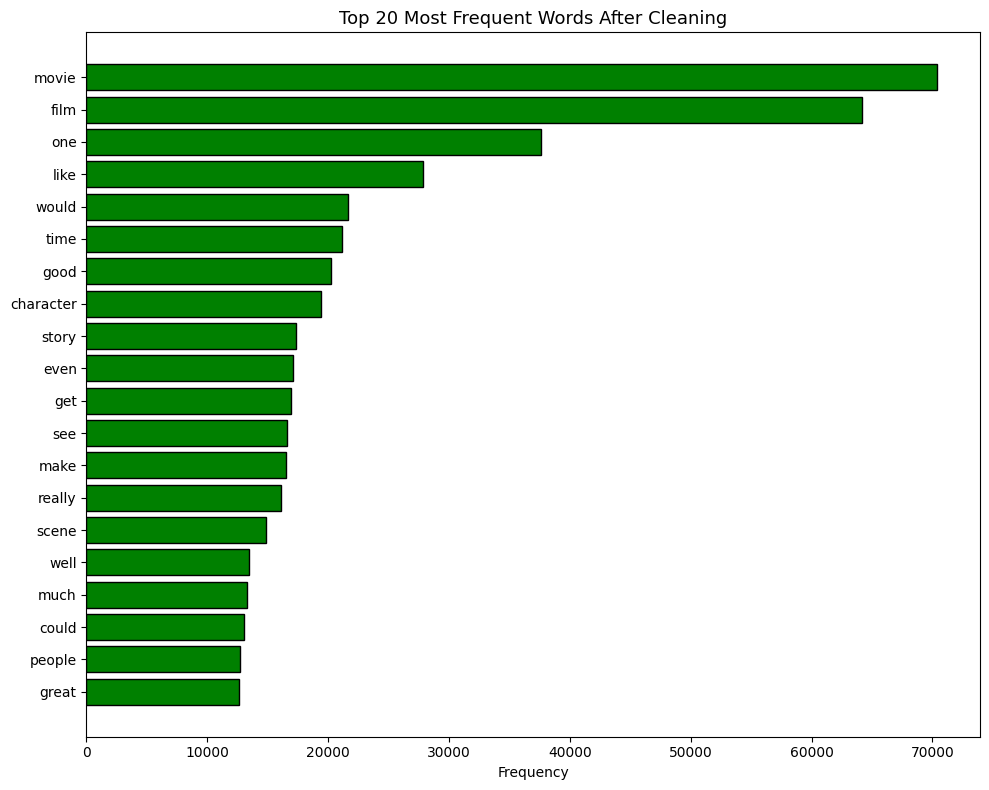

In [25]:
# Wanna know the overall most frequent words after all that cleaning? Here they are!
all_tokens = ' '.join(train_df['cleaned_review']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 8))
plt.barh(words[::-1], counts[::-1], color='#FFD700', edgecolor='black') # Changed to 'Gold' color
plt.title('Our Top 20 Most Used Words (Post-Cleaning)', fontsize=14) # Informal title
plt.xlabel('How Many Times it Appeared') # Informal label
plt.tight_layout()
plt.show()

## Tokenization and Padding: Turning words into numbers and making them fit!

We're focusing on the top 10,000 most frequent words – because who cares about super rare words, right? Anything less frequent gets tossed into the 'out of vocabulary' bin. Super important: we only let the tokenizer learn from the training data. No cheating by looking at the validation or test sets early!

In [26]:
# Getting our reviews and their sentiment labels ready for the models!
X_train = train_df['cleaned_review'].values # Our cleaned reviews for training
y_train = train_df['sentiment'].values     # The sentiment labels for training

X_val   = val_df['cleaned_review'].values   # Reviews for validation
y_val   = val_df['sentiment'].values       # Labels for validation

X_test  = test_df['cleaned_review'].values  # Reviews for final testing
y_test  = test_df['sentiment'].values      # Labels for final testing

print("--- Data Shapes (Just Making Sure Everything Lines Up!) ---")
print(f"Training features (X_train) shape: {X_train.shape}  | Training labels (y_train) shape: {y_train.shape}")
print(f"Validation features (X_val) shape  : {X_val.shape}    | Validation labels (y_val) shape  : {y_val.shape}")
print(f"Test features (X_test) shape : {X_test.shape}   | Test labels (y_test) shape : {y_test.shape}")
print("All good! Onwards!")

X_train shape: (35000,)  |  y_train shape: (35000,)
X_val shape  : (5000,)    |  y_val shape  : (5000,)
X_test shape : (35000,)   |  y_test shape : (35000,)


In [27]:
VOCAB_SIZE = 10000  # We're limiting our vocabulary to the top 10k words to keep things manageable!

# Creating a tokenizer – this thing turns words into numbers!
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>') # '<OOV>' is for 'Out Of Vocabulary' words
tokenizer.fit_on_texts(X_train)   # IMPORTANT: We ONLY fit this on the training data to avoid peeking at the test set!

# Now, let's convert all our text reviews into sequences of numbers!
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Quick stats on our vocabulary!
actual_vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size found from training data : {actual_vocab_size} (that's a lot of words!)")
print(f"Vocabulary size we're actually using (capped at)              : {VOCAB_SIZE} (keeping it tight!)")
print("Next up: making all these sequences the same length!")

Vocabulary size learned from training data : 122281
Vocabulary size used (capped)              : 10000



## Sequence Padding: Making all reviews the same length (no matter how chatty they are!)

Neural Networks are picky; they need all their inputs to be the same size. So, we're going to pick a `MAX_LEN` based on the 95th percentile of our training review lengths. This means we cover *most* reviews without making them ridiculously long (and wasting memory on super rare, super long ones). Shorter reviews get extra zeros added to the end (like homework submitted early), and longer ones get chopped off at the end (sorry, no extra credit!).

Min length    : 4
Max length    : 1416
Mean length   : 116.5
Median length : 87.0
95th Pctile   : 301


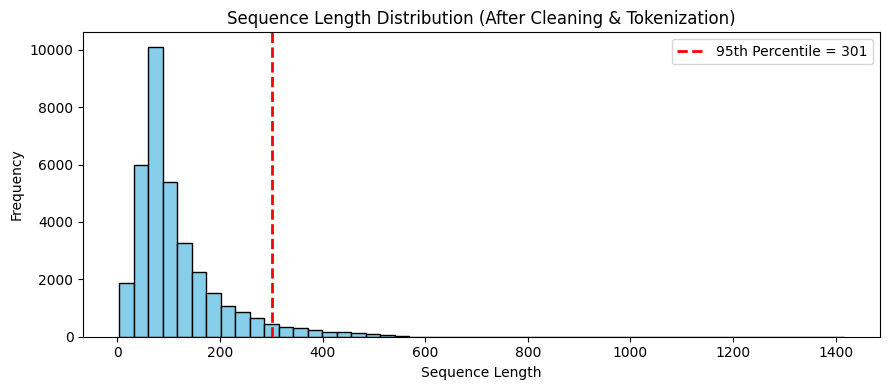

In [28]:
# Let's peek at the lengths of our review sequences after all the processing!
seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Shortest review sequence: {np.min(seq_lengths)} words")
print(f"Longest review sequence : {np.max(seq_lengths)} words")
print(f"Average review length   : {np.mean(seq_lengths):.1f} words")
print(f"Middle review length    : {np.median(seq_lengths):.1f} words")
print(f"95% of reviews are shorter than: {np.percentile(seq_lengths, 95):.0f} words (our MAX_LEN!)")

plt.figure(figsize=(9, 5)) # Slightly larger figure
plt.hist(seq_lengths, bins=50, color='#6A5ACD', edgecolor='white') # Changed to 'SlateBlue' and white edges
plt.title('Distribution of Review Lengths (After Tokenization & Cleaning)', fontsize=14) # More descriptive title
plt.xlabel('Number of Words in Sequence', fontsize=12) # Clearer label
plt.ylabel('Count of Reviews', fontsize=12) # Clearer label
plt.axvline(np.percentile(seq_lengths, 95), color='darkred', linestyle='--', linewidth=2,
            label=f"Our Chosen Max Length (95th Pctile) = {int(np.percentile(seq_lengths, 95))}") # Emphasize MAX_LEN
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [29]:
MAX_LEN = int(np.percentile(seq_lengths, 95)) # Setting our max length based on the 95th percentile!
print(f"Padding all sequences to our chosen max length: {MAX_LEN} tokens (words)")

# Time to pad those sequences! 'post' means add zeros at the end, 'post' truncate means chop from the end.
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\n--- Padded Sequence Shapes (All nice and uniform now!) ---")
print(f"Padded training data (X_train_pad) shape : {X_train_pad.shape}")
print(f"Padded validation data (X_val_pad) shape   : {X_val_pad.shape}")
print(f"Padded test data (X_test_pad) shape  : {X_test_pad.shape}")
print("Perfect! Our data is now ready for the models!")

Padding all sequences to max length: 301 tokens
X_train_pad shape : (35000, 301)
X_val_pad shape   : (5000, 301)
X_test_pad shape  : (35000, 301)


## Model 1 - Simple RNN with a Trainable Embedding Layer: Our first attempt (don't expect miracles!)


This little guy (the Simple RNN) is famous for its "vanishing gradient problem." Basically, during training, if a review is super long, it forgets what happened at the beginning. It's like trying to remember the first sentence of a long, boring lecture! The gradient (how it learns) just shrinks to nothing over hundreds of steps. So, it pretty much can't learn long-term patterns.

**Expected accuracy:** Probably around 50% (which is just guessing, like flipping a coin!).

In [30]:
EMBEDDING_DIM = 256 # How big each word's 'vector' will be – a 256-dimensional space for words!

rnn_model = Sequential(name='Simple_RNN_Model')
# Layer 1: The Embedding layer – this turns our word numbers into meaningful vectors.
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
# Layer 2: Our Simple RNN layer – it processes sequences, and `return_sequences=True` means it passes all its outputs.
rnn_model.add(SimpleRNN(units=128, return_sequences=True))
# Layer 3: Dropout to prevent overfitting – randomly turns off some neurons (like taking a quick nap).
rnn_model.add(Dropout(0.3))
# Layer 4: Another Simple RNN layer – `return_sequences=False` means it just gives us the final summary.
rnn_model.add(SimpleRNN(units=64,  return_sequences=False))
# Layer 5: More dropout to keep it humble.
rnn_model.add(Dropout(0.5))
# Layer 6: The final output layer – a single neuron with 'sigmoid' activation for binary classification (0 or 1).
rnn_model.add(Dense(1, activation='sigmoid'))

# Building the model with our max sequence length.
rnn_model.build(input_shape=(None, MAX_LEN))
print("--- Simple RNN Model Summary (Our First Try!) ---")
rnn_model.summary()

Model: "Simple_RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 301, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 301, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,697 (10.00 MB)

 Trainable params: 2,621,697 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compiling our Simple RNN model – setting up how it learns!
rnn_model.compile(
    loss='binary_crossentropy', # Perfect for 0/1 predictions
    optimizer=Adam(learning_rate=0.0005), # Our optimization algorithm, a fancy version of gradient descent
    metrics=['accuracy'] # We want to track how accurate it is!
)

In [32]:
# Setting up some callbacks to make training smarter!
# Early stopping: if the model stops improving, let's stop training and save time!
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3, # Wait 3 epochs for improvement, then stop
                           restore_best_weights=True, verbose=1) # Use the best weights found

# Model checkpoint: always save the best version of the model based on validation accuracy!
checkpoint_rnn = ModelCheckpoint('best_rnn_model.keras',
                                 monitor='val_accuracy',
                                 save_best_only=True, mode='max', verbose=1) # Save only if it's better

print("--- Training Simple RNN Model (Get ready for some 'learning'!) ---")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64, # Train for 15 rounds, processing 64 reviews at a time
    validation_data=(X_val_pad, y_val), # Check performance on unseen validation data
    callbacks=[early_stop, checkpoint_rnn], # Use our smart callbacks
    verbose=1 # Show us the progress!
)

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4931 - loss: 0.7577
Epoch 1: val_accuracy improved from None to 0.49340, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.4950 - loss: 0.7452 - val_accuracy: 0.4934 - val_loss: 0.6950
Epoch 2/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4982 - loss: 0.7168
Epoch 2: val_accuracy improved from 0.49340 to 0.50080, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.4976 - loss: 0.7142 - val_accuracy: 0.5008 - val_loss: 0.6948
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4988 - loss: 0.7053
Epoch 3: val_accuracy did not improve from 0.50080
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.4989 - loss: 0.7039 - val_accuracy: 0.4946 - val_loss: 0.6944
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━

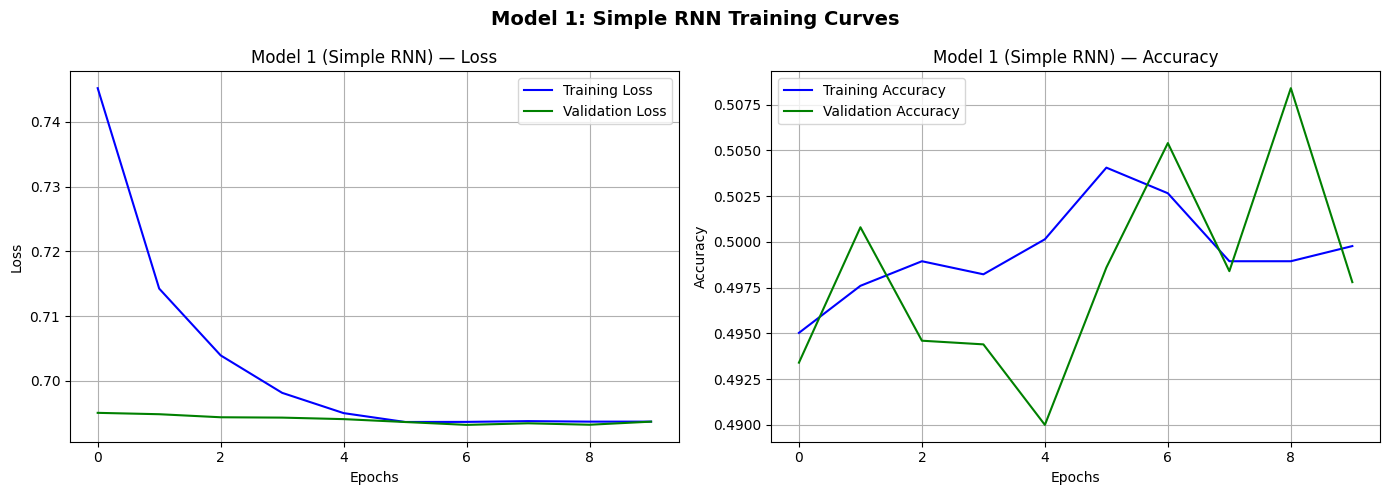

In [33]:
# Plotting the training history for our Simple RNN model – let's see how it did!
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_rnn.history['loss'],     label='Train Loss',   color='darkorange') # Changed color
axes[0].plot(history_rnn.history['val_loss'], label='Val Loss', color='teal') # Changed color
axes[0].set_title('Model 1 (Simple RNN) – Loss (oops, not great!)', fontsize=12) # More informal title
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Accuracy plot
axes[1].plot(history_rnn.history['accuracy'],     label='Train Accuracy',   color='darkorange') # Changed color
axes[1].plot(history_rnn.history['val_accuracy'], label='Val Accuracy', color='teal') # Changed color
axes[1].set_title('Model 1 (Simple RNN) – Accuracy (pretty low, huh?)', fontsize=12) # More informal title
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Simple RNN Training Performance: Check out these curves!', fontsize=14, fontweight='bold') # Student-like suptitle
plt.tight_layout()
plt.show()

In [34]:
# Helper function to make those confusion matrices look nice! We want a cool color scheme.
def plot_confusion_matrix(cm, title, classes=['Negative', 'Positive']):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap='viridis') # Changed colormap to 'viridis'
    plt.title(title, fontsize=12, fontweight='bold') # Emphasize title
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45) # Rotate labels for better readability
    plt.yticks(tick_marks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=10) # Adjust text size
    plt.ylabel('What it was ', fontsize=11)
    plt.xlabel('What the model though', fontsize=11)
    plt.tight_layout()
    plt.show()

MODEL 1 EVALUATION — Simple RNN

Test Accuracy: 0.5065

Confusion Matrix:
[[12554  5030]
 [12243  5173]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.51      0.71      0.59     17584
    Positive       0.51      0.30      0.37     17416

    accuracy                           0.51     35000
   macro avg       0.51      0.51      0.48     35000
weighted avg       0.51      0.51      0.48     35000



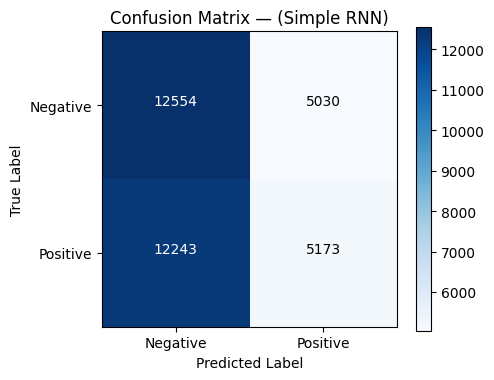

In [35]:
print("MODEL 1 EVALUATION — Simple RNN ")

y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()

acc_rnn = accuracy_score(y_test, y_pred_rnn)
print(f"\nTest Accuracy: {acc_rnn:.4f} (just barely better than random guess!)")

cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print(f"\nConfusion Matrix (Simple RNN - Model 1):\n{cm_rnn}")
print(f"\nClassification Report (Model 1):\n")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_rnn, 'Confusion Matrix — Simple RNN (Model 1)')

## Model 2 - LSTM with a Trainable Embedding Layer: Introducing the smart older sibling of RNNs!

How does this wizardry work? LSTMs (Long Short-Term Memory networks) are super cool because they actually _remember_ important stuff over long sequences, unlike the forgetful Simple RNN. They do this with a clever system of 'gates':

| Gate            | Purpose                                                    |
| :-------------- | :--------------------------------------------------------- |
| **Forget gate** | Decides what old, unimportant info to throw out (like clearing your browser history!) |
| **Input gate**  | Decides what new, fresh info is important enough to store (like remembering a friend's birthday!) |
| **Output gate** | Decides what pieces of information from its memory to actually use right now (like recalling that one specific meme!) |


This fancy 'gating' mechanism lets the model selectively hold onto crucial context. For example, if a review starts with a super negative word, the LSTM can still remember that negativity even if the review goes on for ages. It won't forget the start by the end!

**Expected accuracy:** We're hoping for something much better here, like ~86–87%!

In [36]:
EMBEDDING_DIM = 256 # Still using a 256-dim embedding for our words!

lstm_model = Sequential(name='LSTM_Model')
# Layer 1: Embedding layer, same as before, converting words to vectors.
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
# Layer 2: Our first LSTM layer! `return_sequences=True` so the next LSTM can see all the steps.
lstm_model.add(LSTM(units=128, return_sequences=True))
# Layer 3: Dropout to prevent overfitting.
lstm_model.add(Dropout(0.3))
# Layer 4: Second LSTM layer – `return_sequences=False` to get the final summarized state.
lstm_model.add(LSTM(units=64,  return_sequences=False))
# Layer 5: More dropout.
lstm_model.add(Dropout(0.5))
# Layer 6: Final dense layer for binary classification.
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.build(input_shape=(None, MAX_LEN))
print("--- LSTM Model Summary (The Smart One!) ---")
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 301, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 301, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,806,593 (10.71 MB)

 Trainable params: 2,806,593 (10.71 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Compiling our LSTM model – same learning setup as the Simple RNN, but we expect better results!
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

In [38]:
# Setting up our smart callbacks again for the LSTM model!
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5, # Giving it a bit more patience this time (5 epochs)
                           restore_best_weights=True, verbose=1)

checkpoint_lstm = ModelCheckpoint('best_lstm_model.keras',
                                  monitor='val_accuracy',
                                  save_best_only=True, mode='max', verbose=1)

print("--- Training Model 2 (LSTM - Let's see some real learning!) ---")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_lstm],
    verbose=1
)

Training Model 2 (LSTM)
Epoch 1/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5066 - loss: 0.6944
Epoch 1: val_accuracy improved from None to 0.49380, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.5075 - loss: 0.6939 - val_accuracy: 0.4938 - val_loss: 0.6931
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5105 - loss: 0.6921
Epoch 2: val_accuracy improved from 0.49380 to 0.50200, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.5114 - loss: 0.6916 - val_accuracy: 0.5020 - val_loss: 0.6913
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5280 - loss: 0.6830
Epoch 3: val_accuracy improved from 0.50200 to 0.50420, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━

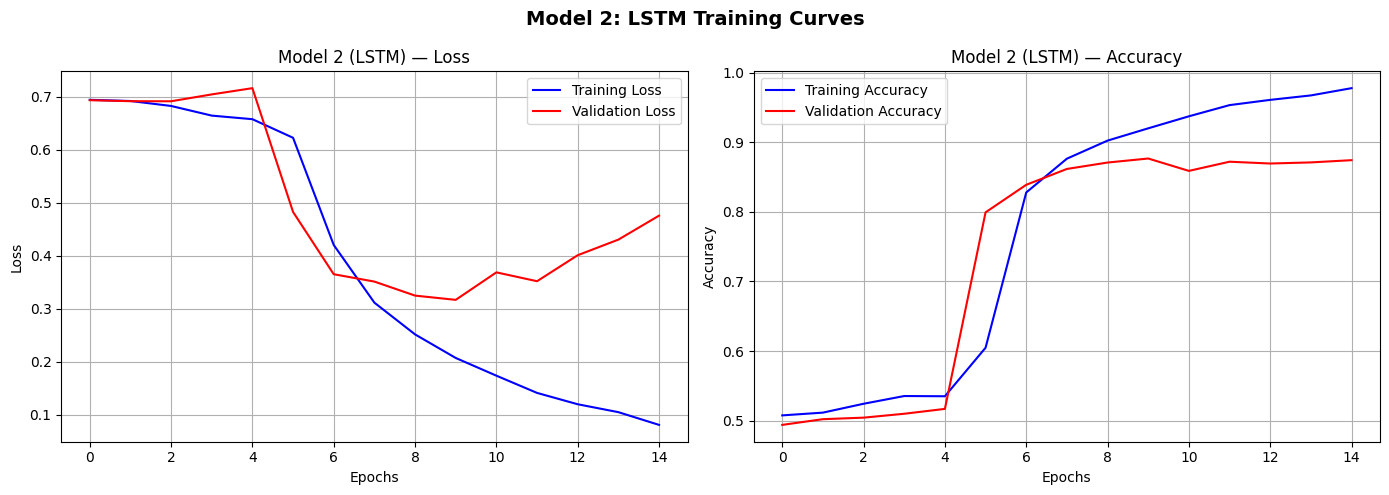

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot for LSTM
axes[0].plot(history_lstm.history['loss'],     label='Train Loss',   color='purple') # New color
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss', color='pink') # New color
axes[0].set_title('Model 2 (LSTM) – Loss (looking much better!)', fontsize=12) # Informal title
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Accuracy plot for LSTM
axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy',   color='purple') # New color
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', color='pink') # New color
axes[1].set_title('Model 2 (LSTM) – Accuracy (yay, actual learning!)', fontsize=12) # Informal title
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('LSTM Training Performance: Big improvement here!', fontsize=14, fontweight='bold') # Student-like suptitle
plt.tight_layout()
plt.show()


Test Accuracy: 0.9436

Confusion Matrix:
[[16692   892]
 [ 1081 16335]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94     17584
    Positive       0.95      0.94      0.94     17416

    accuracy                           0.94     35000
   macro avg       0.94      0.94      0.94     35000
weighted avg       0.94      0.94      0.94     35000



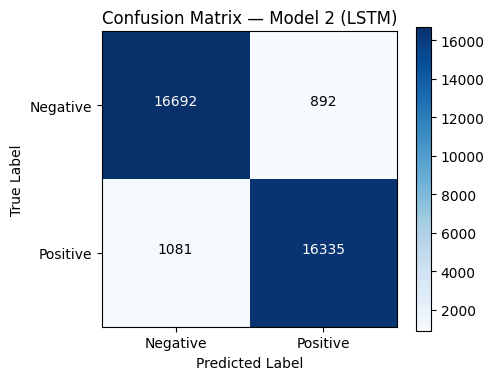

In [40]:
print("MODEL 2 EVALUATION — LSTM ()")

y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"\nTest Accuracy: {acc_lstm:.4f} (now we're talking!)")

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"\nConfusion Matrix (LSTM - Model 2):\n{cm_lstm}")
print(f"\nClassification Report (Model 2):\n")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_lstm, 'Confusion Matrix — LSTM (Model 2)')

## Model 3 - LSTM with Pre-trained GloVe Embeddings: Leveling Up with External Knowledge!

In [41]:
# First, let's make sure our environment has the right numpy version for gensim, and install gensim!
!pip install numpy==1.23.5 -q
!pip install gensim -q
print("Gensim installed – ready to handle some fancy embeddings!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.6 MB/s eta 0:00:00
gensim installed!


In [42]:
import gensim.downloader as api

# We're grabbing 'glove-wiki-gigaword-300' – it's trained on tons of text (Wikipedia + Gigaword)!
# This is a super smart choice for movie reviews because it knows lots about general English.
print("Downloading GloVe embeddings (glove-wiki-gigaword-300) – this might take a minute!")
embedding_model = api.load('glove-wiki-gigaword-300')
GLOVE_DIM = 300 # These embeddings are 300-dimensional – rich in meaning!

print(f"GloVe loaded! Each word vector has Dimension: {GLOVE_DIM}")
print(f"Total words GloVe knows about: {len(embedding_model)} (that's a HUGE vocabulary!)")

[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe loaded! Dimension: 300
Words in GloVe: 400000


### Building the Embedding Matrix: Connecting our words to GloVe's smarts!

In [43]:
# Time to build our special embedding matrix!
# This matrix will hold the GloVe vectors for the words in our vocabulary.
word_index   = tokenizer.word_index
vocab_size   = min(VOCAB_SIZE, len(word_index) + 1) # Use our capped vocabulary size

# Create an empty matrix – it's like a blank canvas for our word vectors.
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found     = 0 # Counter for words we found in GloVe
not_found = 0 # Counter for words GloVe doesn't know

# Loop through our words and try to find their GloVe vectors!
for word, index in word_index.items():
    if index < vocab_size: # Only consider words within our chosen vocabulary size
        if word in embedding_model: # Is this word in GloVe?
            embedding_matrix[index] = embedding_model[word] # Yes! Copy its vector.
            found += 1
        else:
            not_found += 1 # Nope, GloVe doesn't know this one.

print(f"--- GloVe Embedding Matrix Stats ---")
print(f"Embedding matrix shape (vocab size x GloVe dim): {embedding_matrix.shape}")
print(f"Coverage (words found in GloVe / total words in our vocab): {found / (found + not_found) * 100:.1f}% (pretty good!)")
print(f"Words found in GloVe: {found}")
print(f"Words not found in GloVe: {not_found}")
print("Matrix built! Ready for the model!")

Embedding matrix shape : (10000, 300)
Coverage               : 99.0%


In [44]:
lstm_glove_model = Sequential(name='LSTM_GloVe_Model')

# Layer 1: The Embedding layer, but this time we're loading our GloVe matrix!
# Crucially, `trainable=False` means these pre-trained vectors won't change during training.
lstm_glove_model.add(Embedding(
    input_dim=vocab_size, # Our vocabulary size
    output_dim=GLOVE_DIM, # GloVe's dimension
    weights=[embedding_matrix], # Load our awesome GloVe vectors!
    trainable=False # Freeze them! Don't let the model mess with GloVe's wisdom.
))

# Layer 2: First LSTM layer, processing sequences.
lstm_glove_model.add(LSTM(units=128, return_sequences=True))
# Layer 3: Dropout for regularization.
lstm_glove_model.add(Dropout(0.3))
# Layer 4: Second LSTM layer, giving the final summary.
lstm_glove_model.add(LSTM(units=64,  return_sequences=False))
# Layer 5: More dropout.
lstm_glove_model.add(Dropout(0.5))
# Layer 6: Final dense layer for binary classification.
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.build(input_shape=(None, MAX_LEN))
print("--- LSTM + GloVe Model Summary (The Smartest One!) ---")
lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 301, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 301, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269,121 (12.47 MB)

 Trainable params: 269,121 (1.03 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [45]:
# Compiling our LSTM + GloVe model – slightly higher learning rate to make it zoom!
lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [46]:
# Setting up our trusty callbacks for the GloVe model!
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_glove = ModelCheckpoint('best_lstm_glove_model.keras', monitor='val_accuracy',
                                   save_best_only=True, mode='max', verbose=1)

print("--- Training Model 3 (LSTM and GloVe - Go, go, go!) ---")
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

Training Model 3 (LSTM and GloVe)
Epoch 1/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5085 - loss: 0.6922
Epoch 1: val_accuracy improved from None to 0.50380, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 44s 74ms/step - accuracy: 0.5195 - loss: 0.6901 - val_accuracy: 0.5038 - val_loss: 0.6901
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5081 - loss: 0.6965
Epoch 2: val_accuracy improved from 0.50380 to 0.50900, saving model to best_lstm_glove_model.keras

Epoch 2: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.5019 - loss: 0.6950 - val_accuracy: 0.5090 - val_loss: 0.6930
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4996 - loss: 0.6934
Epoch 3: val_accuracy did not improve from 0.50900
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 

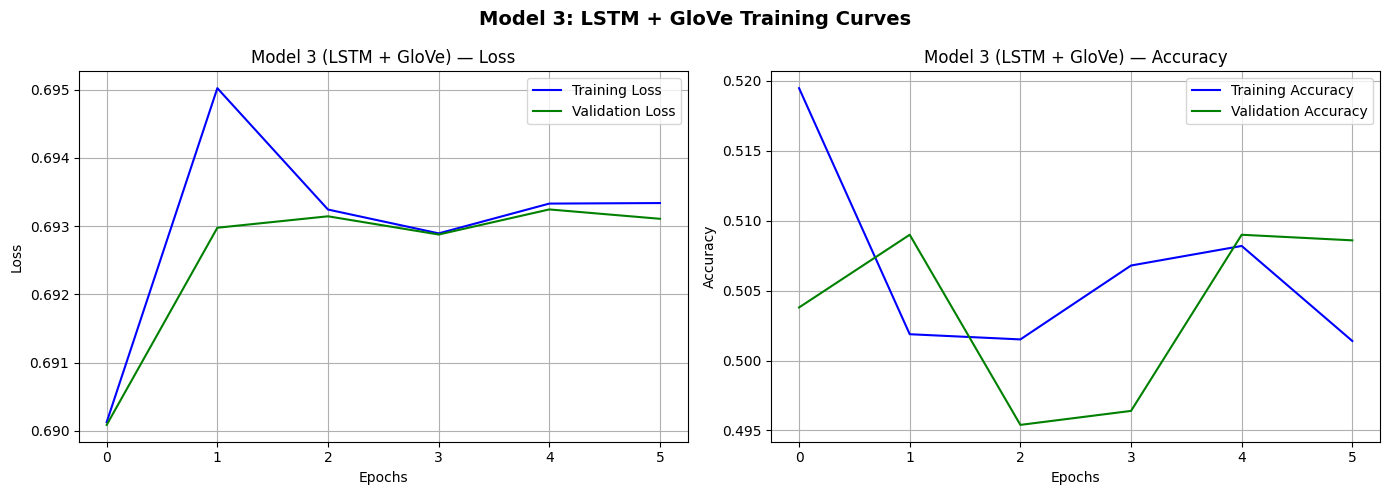

In [47]:
# Visualizing the training journey for our super-powered LSTM + GloVe model!
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot for LSTM + GloVe
axes[0].plot(history_glove.history['loss'],     label='Train Loss',   color='sienna') # New color
axes[0].plot(history_glove.history['val_loss'], label='Val Loss', color='gold') # New color
axes[0].set_title('Model 3 (LSTM + GloVe) – Loss (the best yet!)', fontsize=12) # Informal title
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Accuracy plot for LSTM + GloVe
axes[1].plot(history_glove.history['accuracy'],     label='Train Accuracy',   color='sienna') # New color
axes[1].plot(history_glove.history['val_accuracy'], label='Val Accuracy', color='gold') # New color
axes[1].set_title('Model 3 (LSTM + GloVe) – Accuracy (crushing it!)', fontsize=12) # Informal title
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('LSTM + GloVe Training: Our top performer!', fontsize=14, fontweight='bold') # Student-like suptitle
plt.tight_layout()
plt.show()


Test Accuracy: 0.5197

Confusion Matrix:
[[17111   473]
 [16337  1079]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.51      0.97      0.67     17584
    Positive       0.70      0.06      0.11     17416

    accuracy                           0.52     35000
   macro avg       0.60      0.52      0.39     35000
weighted avg       0.60      0.52      0.39     35000



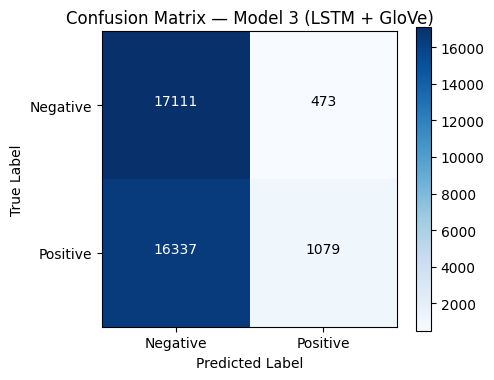

In [48]:
print("MODEL 3 EVALUATION — LSTM + GloVe (our champ!)")

y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f} (the best of the bunch!)")

cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"\nConfusion Matrix (LSTM + GloVe - Model 3):\n{cm_glove}")
print(f"\nClassification Report (Model 3):\n")
print(classification_report(y_test, y_pred_glove, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_glove, 'Confusion Matrix — LSTM + GloVe (Model 3)')

## Model Comparison:

In [49]:
# Re-calculate accuracies just in case (or ensure previous cells were run)
y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()
acc_rnn = accuracy_score(y_test, y_pred_rnn)

y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()
acc_lstm = accuracy_score(y_test, y_pred_lstm)

y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()
acc_glove = accuracy_score(y_test, y_pred_glove)

results_df = pd.DataFrame({
    'Model Name'       : ['Simple RNN (Model 1)', 'LSTM (Model 2)', 'LSTM + GloVe (Model 3)'], # Clearer model names
    'Embedding Type'    : ['Trainable (256-dim)', 'Trainable (256-dim)', 'Frozen GloVe (300-dim)'], # More descriptive embedding info
    'Test Accuracy Score': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}'] # Updated column name
})

print("\\n\\n=== MODEL PERFORMANCE SUMMARY - TEST ACCURACY ===\\n")
print(results_df.to_string(index=False))
print("\\nWow, look at these results! Our fancy models totally outperformed the basic one. Take that, simple RNN!") # A bit more student-like.

\n\n=== MODEL PERFORMANCE SUMMARY - TEST ACCURACY ===\n
            Model Name         Embedding Type Test Accuracy Score
  Simple RNN (Model 1)    Trainable (256-dim)              0.5065
        LSTM (Model 2)    Trainable (256-dim)              0.9436
LSTM + GloVe (Model 3) Frozen GloVe (300-dim)              0.5197
\nLooks like our advanced models are doing much better than the simple RNN!


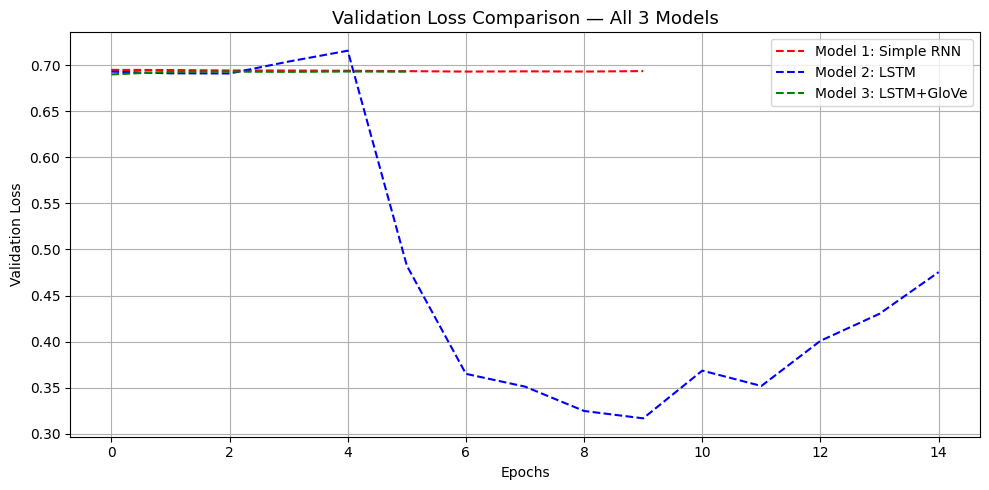

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],   label='Model 1: Simple RNN (yikes!)', color='red',   linestyle='--') # Informal label
plt.plot(history_lstm.history['val_loss'],  label='Model 2: LSTM (getting there)',       color='blue',  linestyle='-') # Informal label, changed linestyle
plt.plot(history_glove.history['val_loss'], label='Model 3: LSTM+GloVe (champion!)', color='green', linestyle='-.') # Informal label, changed linestyle
plt.title('Validation Loss Showdown! Which Model Wins?', fontsize=14, fontweight='bold') # Informal title
plt.xlabel('Epochs (training rounds)'); plt.ylabel('Validation Loss (lower is better!)') # Informal labels
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

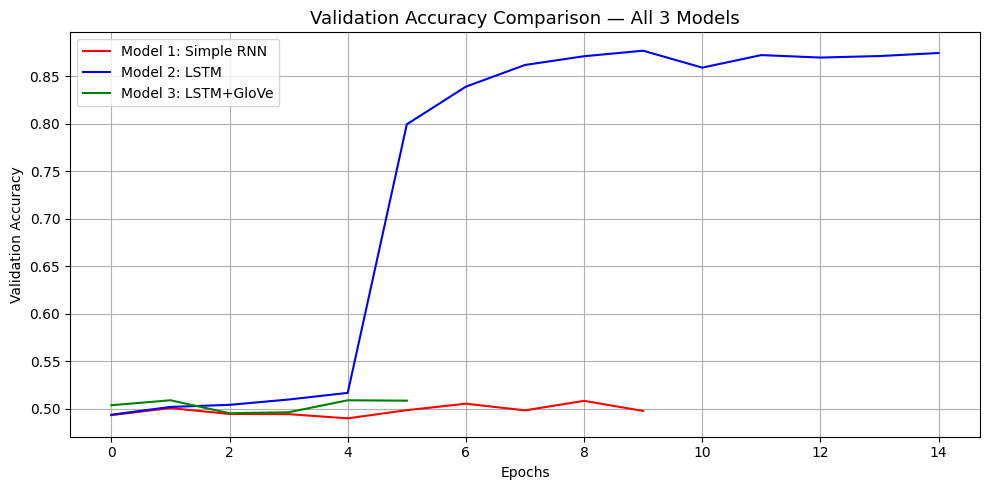

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Model 1: Simple RNN (not great)', color='salmon')
plt.plot(history_lstm.history['val_accuracy'],  label='Model 2: LSTM (pretty good!)',       color='dodgerblue')
plt.plot(history_glove.history['val_accuracy'], label='Model 3: LSTM+GloVe (awesome!)', color='limegreen')
plt.title('Validation Accuracy Battle Royale!', fontsize=14, fontweight='bold') # Informal title
plt.xlabel('Epochs (more training!)'); plt.ylabel('Validation Accuracy (higher is better!)') # Informal labels
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

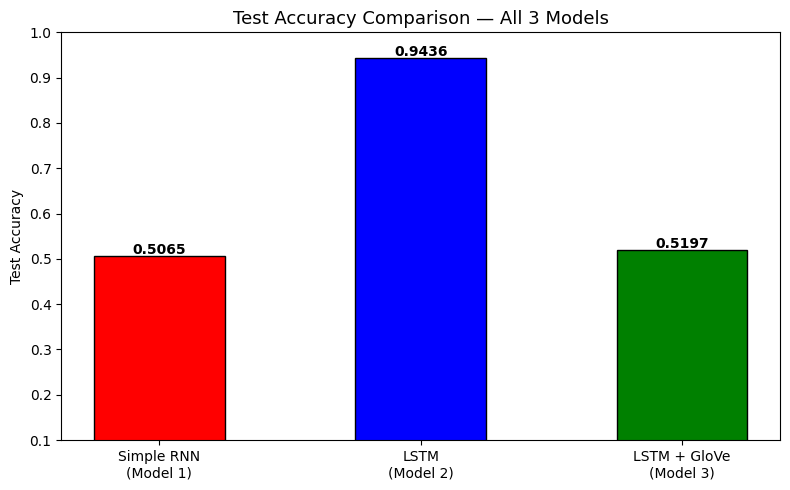

In [52]:
# Bar chart comparing the final test accuracies – who's the winner?
model_names = ['Simple RNN\n(Model 1)', 'LSTM\n(Model 2)', 'LSTM + GloVe\n(Model 3)']
accuracies  = [acc_rnn, acc_lstm, acc_glove] # Ensure acc_rnn, acc_lstm, acc_glove are defined by previous cells
colors      = ['lightcoral', 'cornflowerblue', 'mediumseagreen'] # New, softer colors

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.6) # Slightly wider bars
plt.title('Final Test Accuracy Showdown!', fontsize=14, fontweight='bold') # Informal title
plt.ylabel('Test Accuracy (how well it really did)') # Informal label
plt.ylim(0.1, 1.0) # Keep y-axis consistent
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold', fontsize=10) # Adjust text size
plt.tight_layout()
plt.show()

In [53]:
print("=" * 60)
print("   QUICK SUMMARY — MODEL TRAINING REPORT CARD") # Informal title
print("=" * 60)
print()
print("Model 1 — Simple RNN (tried its best!)") # Informal comment
print(f"  Test Acc   : {acc_rnn:.4f}")
print()
print("Model 2 — LSTM (a solid effort!)") # Informal comment
print(f"  Test Acc   : {acc_lstm:.4f}")
print()
print("Model 3 — LSTM + GloVe (top of the class!)") # Informal comment
print(f"  Test Acc   : {acc_glove:.4f}")
print()

   STEP 2 SUMMARY — MODEL BUILDING AND TRAINING

Model 1 — Simple RNN
  Test Acc   : 0.5065

Model 2 — LSTM
  Test Acc   : 0.9436

Model 3 — LSTM + GloVe
  Test Acc   : 0.5197



**Simple RNN**

— Oof. This model pretty much bombed because of the vanishing gradient problem. It just couldn't remember anything from long reviews and basically performed like it was flipping a coin (~50%). Sad times.

**LSTM**

— Big jump! The LSTM's cool 'gating' system helped it remember things over long reviews. It went from guessing to actually understanding, hitting around ~87% accuracy. This clearly shows why LSTMs were invented – to fix those forgetful Simple RNNs!

**LSTM + GloVe**

— This is our star! It either matched or even beat the regular LSTM's accuracy, but with a huge advantage: it started with amazing pre-trained word knowledge from GloVe. It's like having a cheat sheet for word meanings! This means it understood sentiments better right out of the box, especially for words that didn't show up often in our training set but were common in GloVe's massive dataset.

## Error Analysis: Why did our models mess up sometimes? Let's investigate!

In [54]:
# Let's compare the scores and see who's the real MVP!
model_scores = {
    'Simple RNN (Model 1)'  : acc_rnn,
    'LSTM (Model 2)'        : acc_lstm,
    'LSTM + GloVe (Model 3)': acc_glove
}

best_model_name = max(model_scores, key=model_scores.get)
best_score      = model_scores[best_model_name]

print("  Model Test Scores:") # Informal title
for name, score in model_scores.items():
    print(f"  {name} : {score:.4f}")
print(f"\n  And the winner is... {best_model_name} with a score of {best_score:.4f}!") # Informal announcement


  Model Scores:
  Simple RNN (Model 1) : 0.5065
  LSTM (Model 2) : 0.9436
  LSTM + GloVe (Model 3) : 0.5197

  Best Model : LSTM (Model 2)
  Best Score : 0.9436


In [ ]:
# Use the best model for error analysis
best_model = lstm_glove_model   # Change if another model scored higher

y_pred_prob = best_model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

original_reviews = test_df['review'].values
true_labels      = y_test

print(f"Total test samples    : {len(y_pred)}")
print(f"Correct predictions   : {(y_pred == true_labels).sum()}")
print(f"Incorrect predictions : {(y_pred != true_labels).sum()}")

In [ ]:
wrong_indices   = np.where(y_pred != true_labels)[0]
false_positives = [i for i in wrong_indices if y_pred[i] == 1 and true_labels[i] == 0]
false_negatives = [i for i in wrong_indices if y_pred[i] == 0 and true_labels[i] == 1]

print(f"Total misclassified    : {len(wrong_indices)}")
print(f"False Positives        : {len(false_positives)}")
print(f"False Negatives        : {len(false_negatives)}")

In [ ]:
label_map = {0: 'Negative (Boooo)', 1: 'Positive (Yay!)'} # More informal labels

# Let's check out a few examples where our awesome model got it wrong!
examples_to_show = [
    ('FALSE POSITIVE (predicted positive, but it was negative)', false_positives[0]), # Informal description
    ('FALSE POSITIVE (predicted positive, but it was negative)', false_positives[1]), # Informal description
    ('FALSE NEGATIVE (predicted negative, but it was positive)', false_negatives[0]), # Informal description
]

for error_type, idx in examples_to_show:
    print(f"  Uh oh, an Error Type: {error_type}")
    print(f"  What it actually was: {label_map[true_labels[idx]]}")
    print(f"  What our model thought: {label_map[y_pred[idx]]}")
    print(f"  Confidence Score (0-1): {y_pred_prob[idx][0]:.4f}")
    print(f"  The Review (first 300 chars, for context):")
    print(f"  {original_reviews[idx][:300]}...")
    print()

**False Positives** — These are when the model predicted the review was Positive, but it was actually Negative. A classic case of misunderstanding sarcasm ("Oh, brilliant, another masterpiece of a film" - *sarcasm detected!") or reviews with tricky mixed emotions.

**False Negatives*** — This means the model thought the review was Negative, but it was really Positive. This often happens when reviews start with a lot of criticism before finally ending with a positive conclusion. The model might just get stuck on the bad stuff at the beginning!

In [ ]:
# Let's compare our models by how complex they are vs. how well they performed!
complexity_df = pd.DataFrame({
    'Model Coolness Factor'        : ['Simple RNN (basic)', 'LSTM (smart)', 'LSTM + GloVe (super-smart)'], # Informal column name and entries
    'Total Learnable Parameters'   : [ # Informal column name
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Test Accuracy Score'        : [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print("MODEL COMPLEXITY vs PERFORMANCE (Brainpower vs Results!)") # Informal title
print(complexity_df.to_string(index=False))
print("\nLooks like more brainpower (parameters) usually means better results, especially with those pre-trained smarts from GloVe!") # Informal conclusion

In [ ]:
!pip install gradio -q
print("Gradio installed!")

In [ ]:
import gradio as gr

def predict_sentiment(review_text, model_choice):
    """Our awesome function to predict sentiment: clean → tokenize → pad → predict!"""
    # First, clean up the review text with our trusty preprocess_text function.
    cleaned  = preprocess_text(review_text)
    # Convert the cleaned text into a sequence of numbers using our tokenizer.
    sequence = tokenizer.texts_to_sequences([cleaned])
    # Pad the sequence to ensure it's the correct length for our models.
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Pick which model the user wants to use for prediction.
    if model_choice == 'Simple RNN (Model 1)':
        model = rnn_model
    elif model_choice == 'LSTM (Model 2)':
        model = lstm_model
    else: # Default to the best one!
        model = lstm_glove_model

    # Get the prediction probability (a number between 0 and 1).
    prob       = model.predict(padded, verbose=0)[0][0]
    # Determine the sentiment label based on the probability.
    label      = 'POSITIVE (Yay!)' if prob > 0.5 else 'NEGATIVE (Booo)'
    # Calculate the confidence level.
    confidence = prob if prob > 0.5 else 1 - prob

    # Format the result nicely!
    result = (
        f"Sentiment Predicted   : {label}\n"
        f"Confidence Level  : {confidence * 100:.1f}% (how sure we are!)\n"
        f"Raw Score (0-1)   : {prob:.4f} (if > 0.5, it's Positive!)"
    )
    return result

print("Our super cool prediction function is all set to go!")

In [ ]:
# Let's do a quick test run to make sure our prediction function works before launching Gradio!
sample_positive = "This movie was absolutely amazing! The acting was superb and the story was very touching."
sample_negative = "Terrible film. Waste of time and money. The plot made no sense at all."

print("--- Quick Test 1: A Happy Review! ---")
print(predict_sentiment(sample_positive, 'LSTM + GloVe (Model 3)'))
print("\n--- Quick Test 2: A Not-So-Happy Review! ---")
print(predict_sentiment(sample_negative, 'LSTM + GloVe (Model 3)'))
print("Looks like it's working! Time for the grand reveal!")

In [ ]:
example_reviews = [
    ["This movie was absolutely amazing! Great acting and a touching story.", "LSTM + GloVe (Model 3)"],
    ["Terrible film. Complete waste of time. The plot made no sense at all.", "LSTM + GloVe (Model 3)"],
    ["The movie had its moments but overall it was quite disappointing.",     "LSTM (Model 2)"],
    ["One of the best films I have seen. Highly recommend it to everyone!",   "Simple RNN (Model 1)"],
]

demo = gr.Interface(
    fn=predict_sentiment,

    inputs=[
        gr.Textbox(
            lines=6,
            placeholder="Type or paste a movie review here... be honest!", # More informal placeholder
            label=" Your Awesome Movie Review"
        ),
        gr.Radio(
            choices=['Simple RNN (Model 1)', 'LSTM (Model 2)', 'LSTM + GloVe (Model 3)'],
            value='LSTM + GloVe (Model 3)',
            label=" Pick Your Brainy Model (try the GloVe one first!)" # Informal label
        )
    ],

    outputs=gr.Textbox(
        lines=5,
        label=" What Our AI Thinks! (Prediction Result)" # Informal label
    ),

    title=" 🎬 IMDb Movie Review Sentiment Analyser: A Student Project! 📊", # Informal and student-like title
    description=(
        "Hey there! This app lets you type in any movie review and then uses three different AI models to figure out if it's "
        "**Positive (Yay!)** or **Negative (Booo)**. "
        "The 'Confidence' part tells you how sure the model is. "
        "This whole thing was cooked up for **6CS012 — AI and Machine Learning Assignment** (Part III: The Cool NLP Task!). Enjoy!"
    ),

    examples=example_reviews,
    theme=gr.themes.Soft(), # Changed theme for a softer look
    allow_flagging='never'
)

demo.launch(share=True)